<a href="https://colab.research.google.com/github/ajaypadida/OIBSIP-DATASCIENCE/blob/main/Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# 1) Install / import
!pip install --quiet kagglehub pandas matplotlib seaborn

import kagglehub, os, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from zipfile import ZipFile

In [11]:
# 2) Download
raw_path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")
print("raw_path =", raw_path)

raw_path = /kaggle/input/unemployment-in-india


In [12]:
# 3) Unzip if needed
if os.path.isdir(raw_path):
    data_dir = raw_path
else:
    data_dir = "/content/unemployment_data"
    os.makedirs(data_dir, exist_ok=True)
    with ZipFile(raw_path, "r") as z:
        z.extractall(data_dir)

In [13]:
# 4) Load the first CSV we find
csvs = [f for f in os.listdir(data_dir) if f.lower().endswith(".csv")]
print("Found CSVs:", csvs)
df = pd.read_csv(os.path.join(data_dir, csvs[0]))

Found CSVs: ['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [14]:
# 5) Clean up column names (strip whitespace)
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [15]:
# 6) Identify a “date” column (or fall back to year)
if "Date" in df.columns:
    date_col = "Date"
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
elif "fiscal_year" in df.columns:
    # Many forks of this data use 'fiscal_year' like '2023-24'
    # We’ll just take the first 4 digits as year:
    df["Date"] = pd.to_datetime(df["fiscal_year"].str[:4], format="%Y", errors="coerce")
    date_col = "Date"
elif "Year" in df.columns:
    df["Date"] = pd.to_datetime(df["Year"], format="%Y", errors="coerce")
    date_col = "Date"
else:
    raise KeyError(
        "No Date/fiscal_year/Year column found—please inspect df.columns"
    )

/tmp/ipython-input-15-169721019.py:4: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce")


In [16]:
# 7) Rename the unemployment-rate column for convenience
#    (inspect your df.columns output above and adjust the name below if needed)
rate_col = None
for c in df.columns:
    low = c.lower().replace(" ", "").replace("(%)]","")  # strip spaces + % chars
    if "unemployment" in low and "rate" in low:
        rate_col = c
        break
if rate_col is None:
    raise KeyError("Couldn't find an unemployment-rate column—check df.columns")

df = df[[date_col, rate_col, *[c for c in df.columns if c not in (date_col, rate_col)]]]

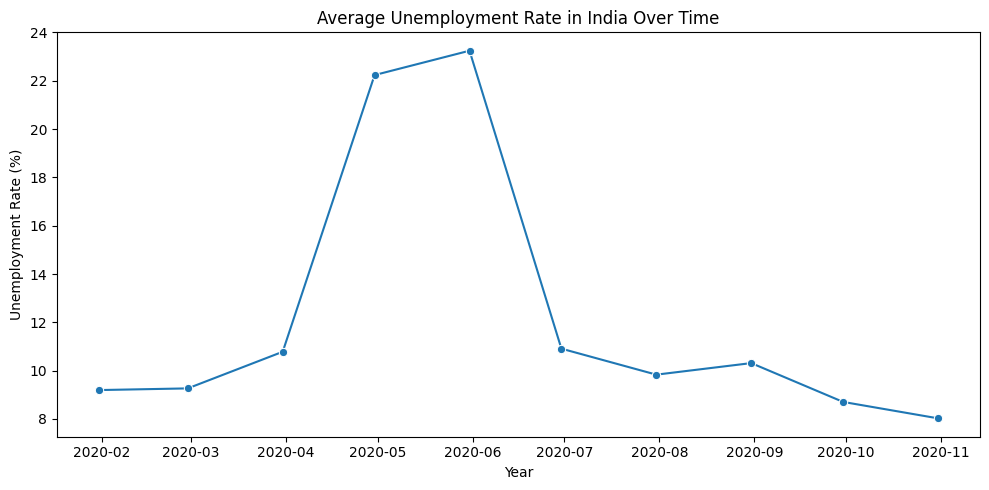

In [17]:
# 8) Quick trend plot for “all India” average
trend = (
    df.groupby(date_col)[rate_col]
      .mean()
      .reset_index()
      .sort_values(date_col)
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x=date_col, y=rate_col, marker="o")
plt.title("Average Unemployment Rate in India Over Time")
plt.xlabel("Year"); plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

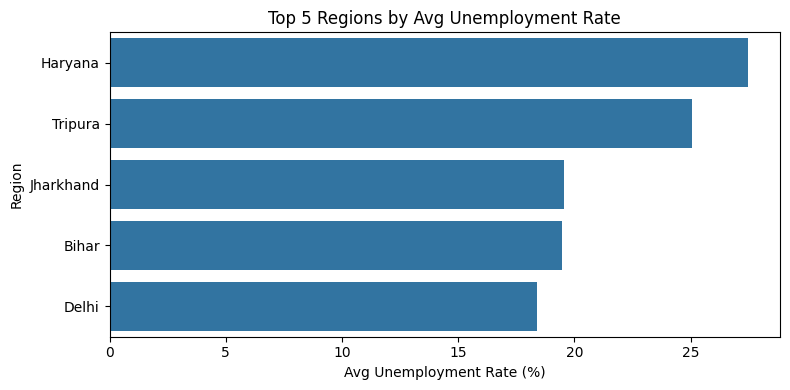

In [18]:

# 9) Top 5 states/regions by average rate
#    (assuming your dataset has a “Region” or “state” column)
group_col = None
for cand in ("Region","region","State","state"):
    if cand in df.columns:
        group_col = cand
        break

if group_col:
    top5 = (
        df.groupby(group_col)[rate_col]
          .mean()
          .nlargest(5)
          .reset_index()
    )
    plt.figure(figsize=(8,4))
    sns.barplot(data=top5, y=group_col, x=rate_col)
    plt.title("Top 5 Regions by Avg Unemployment Rate")
    plt.xlabel("Avg Unemployment Rate (%)")
    plt.ylabel(group_col)
    plt.tight_layout()
    plt.show()
else:
    print("No Region/State column found; skipping bar plot.")